In [1]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

2026-06-02 16:12:53.833931: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-02 16:12:53.894902: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-02 16:12:56.206443: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
import data_degrading as dg
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp


sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_project")
from plot_data import *
from process_data import *


sys.path.insert(0, "/lustre/lrspec/users/4301/snidpy/sourcepy")
from apodize import *
from logwave import Logwave as lw 
from logwave import log_rebin


In [3]:
def folder_to_dataframe(folder, 
                        folder_loc = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/",
                        save_dir = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/folder_parquet",
                        num_wvl = 23411,
                        save = True):
    
    filenames = sorted(glob.glob(folder_loc+ folder +"/*"))
    file_info = [name.split("/")[-1] for name in filenames]
    df_metadata = pd.DataFrame(file_info, columns=["filename"])
    df_metadata[["host", "sn_type", "redshift", "SN_mag", "host_mag"]] = [get_filename_info(info) for info in file_info]
    df_metadata[ "host_mag"] = df_metadata[ "host_mag"].astype(float)
    df_metadata[ "redshift"] = df_metadata[ "redshift"].astype(float)
    df_metadata[ "SN_mag"] = df_metadata[ "SN_mag"].astype(float)

    # set up to extract the X values 
    num_wvl = 23411
    dat_size = len(df_metadata)
    plots = False
    
    X_all = np.zeros((dat_size, num_wvl))
    ABC_IDs = np.zeros((dat_size)) # classification as the float classifier
    Mill_IDs = np.zeros((dat_size)) # classification as the float classifier

    # extract flux and wavelength values from each file 
    for i, filename in enumerate(filenames):
        sep = " " # Define separator for reading data
        s = pd.read_csv(filename, sep=sep, header=None, comment="#") # Read the spectrum data
        wave = s[0]
        X_all[i] = s[1]

        # getting data 
        ABC_type, Mill_type = get_ABC_Mill_type(df_metadata["sn_type"].iloc[i])
        ABC_IDs[i] = ABC_type
        Mill_IDs[i] = Mill_type
        

    # combining metadata and spectra data into single df
    df_metadata["ABC_type"] = ABC_IDs
    df_metadata["Mill_type"] = Mill_IDs    
    df_metadata["Spectral Phase"] = np.zeros((dat_size))
    df_spec = pd.DataFrame(X_all, columns = wave)
    df_folder = pd.concat([df_metadata, df_spec], axis=1)
    df_folder = df_folder.drop(["filename"], axis = 1)

    if save:
        df_folder.to_parquet(os.path.join(save_dir, folder + ".parquet"))

    return df_folder
    

In [4]:
from scipy.interpolate import interp1d

def interp_flux_logspace(log_wave, wvl0, fluxes0):
    # fluxes0 shape: (N_spectra, N_wavelengths)
    f = interp1d(wvl0, fluxes0, axis=1, bounds_error=False, fill_value=0.0)
    return f(log_wave)

def spectrum_logspace(wvl0, fluxes0, w0, w1):
    # need to change cadence and range of data points 
    R_current = np.mean(wvl0[:-1] / np.diff(wvl0)) # current resolution
    nw = dg.calc_num_wvl_bins(R_current, (2500, 10_000)) # number of wavelengths
    w0, w1 = 2_500, 10_000 # wavelength range
    log_wave, wvl0_bin_sizes = dg.calc_new_wvl(R_current, wvl0, (w0, w1)) 
    flux = interp_flux_logspace(log_wave, wvl0, fluxes0) # from logwave  
    return log_wave, flux 
    

  0%|          | 0/1 [00:00<?, ?it/s]/home/4301/miniconda3/envs/abc-env/lib/python3.10/site-packages/pandas/io/parquet.py:191: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = self.api.Table.from_pandas(df, **from_pandas_kwargs)


data loaded into dataframe


/home/4301/miniconda3/envs/abc-env/lib/python3.10/site-packages/pandas/io/parquet.py:191: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = self.api.Table.from_pandas(df, **from_pandas_kwargs)


data preprocessed and saved


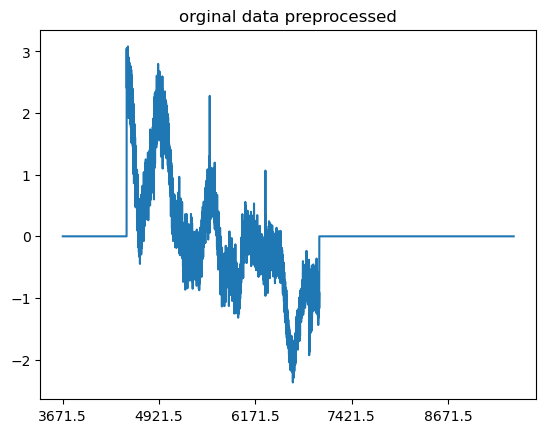

Data put into logspace


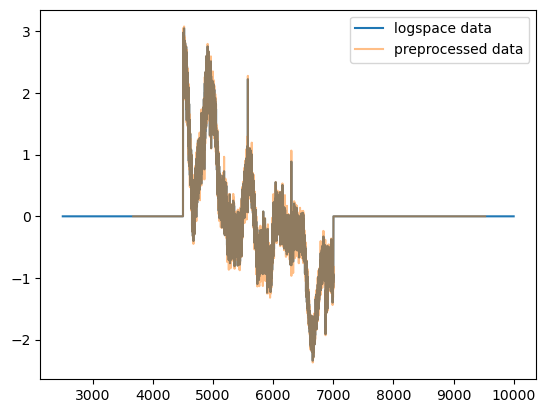

/home/4301/miniconda3/envs/abc-env/lib/python3.10/site-packages/pandas/io/parquet.py:191: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = self.api.Table.from_pandas(df, **from_pandas_kwargs)
100%|██████████| 1/1 [21:34<00:00, 1294.60s/it]

data has been degraded to R = 100
CPU times: user 21min 27s, sys: 2.69 s, total: 21min 30s
Wall time: 21min 34s


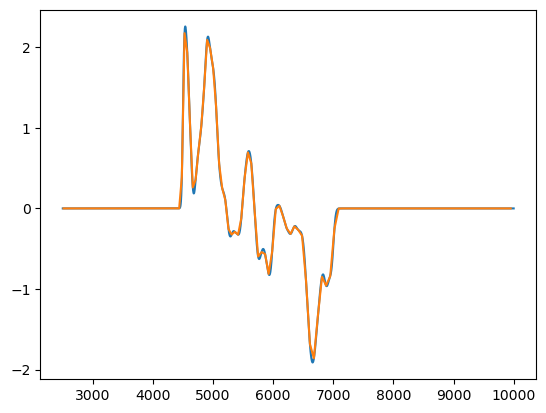

In [5]:
%%time
folder_list = ["kinney_sample1", "kinney_sample2", "kinney_sample3", "kinney_sample4", "kinney_sample5",
               "kinney_sample6", "kinney_sample7", "kinney_sample8", "kinney_sample9",
               "kinney_sample10", "kinney_sample11", "kinney_sample12", "kinney_sample13",
               "kinney_sample14"]
folder_list = ["kinney_sample14"]

plot_print = True
snidify = True
num_data_points = 10
save_dir = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/folder_parquet"

phase_range=(-20, 50)
ptp_range=(-np.inf, np.inf)
wvl_range=(4500, 7000)

for folder in tqdm(folder_list):
    df_folder = folder_to_dataframe(folder)
    if plot_print:
        print("data loaded into dataframe")
    df_prep = preproccess_dataframe(df_folder, phase_range, ptp_range, wvl_range)
    df_prep.to_parquet(os.path.join(save_dir, folder + "_preprocessed.parquet"))
    if plot_print:
        print("data preprocessed and saved")
        df_folder.loc[0].iloc[8:].T.plot()
        plt.title("orginal data preprocessed")
        plt.show()

    # extracting data
    R = 100
    data = dp.extract_dataframe(df_prep)
    index = data[0]  # SN Name for each spectrum
    wvl0 = data[1]  # Wavelength array
    flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
    df_metadata = data[5]  # Sub-dataframe containing only the metadata
    fluxes0 = data[6]  # Only the flux values in a numpy array

    # rebinning the spectra to be in a logspace 
    w0, w1 = 2_500, 10_000 # wavelength range
    log_wave, flux =  spectrum_logspace(wvl0, fluxes0, w0, w1)

    if plot_print:
        print("Data put into logspace")
        plt.plot(log_wave, flux[0], label = "logspace data")
        plt.plot(wvl0, fluxes0[0], alpha =0.5, label = "preprocessed data")
        plt.legend()
        plt.show()

    # normalize spectra using snid 
    if snidify:
        # should trim to exclude zero area
        fnorm, l1, l2, nknot, xknot, yknot = mean_zero(flux)
        
        
    ## code from data_degrade.degrade_dataframe

    # Perform degradation (i.e. lowers resolution) for each spectrum in the dataset. The function
    # # degraded_spectrum is vectorized, so supplying multiple spectrum allows
    # # the operation to be parallelized.
    fluxes_convolve, wvl_degraded, fluxes_degraded = dg.degrade_spectrum(R, log_wave, flux[:num_data_points])
    
    # `wvl_degraded` is actually multiple copies of the same wavelength array, 
    # so we only need the first one.
    degraded_flux_columns = wvl_degraded[0].astype(str)
    
    # Store the convolution data (not the rebinned spectra)
    sn_data_convolve = df_prep.copy(deep=True)
    sn_data_convolve = sn_data_convolve.iloc[:num_data_points]
    sn_data_convolve.loc[:, log_wave] = fluxes_convolve
    
    # Store the rebinned spectra into its own dataframe.
    df_fluxes_degraded = pd.DataFrame(data=fluxes_degraded,
                                      columns=degraded_flux_columns,
                                      index=index[:num_data_points],
                                      dtype=float)
    sn_data_degraded = pd.concat([df_metadata.iloc[:num_data_points], df_fluxes_degraded], axis=1)
    sn_data_convolve.to_parquet(os.path.join(save_dir, folder + "_convoloved.parquet"))
    sn_data_degraded.to_parquet(os.path.join(save_dir, folder + "_rebinned.parquet"))
    
    if plot_print:
        print("data has been degraded to R = 100")
        #shifted data to new wavelength axis but not degraded 
        plt.plot(log_wave, fluxes_convolve[0], label = "convolved fluxed")
        plt.plot(wvl_degraded[0], fluxes_degraded[0], label = "degraded fluxed")
        

In [6]:
mean_zero(flux[0])[0]

array([0., 0., 0., ..., 0., 0., 0.])

In [8]:
%%time
def mean_zero_test(flux):
    return meanzero(flux)[0]
    
snif_flux = np.apply_along_axis(mean_zero_test, 1, flux)

/home/4301/miniconda3/envs/abc-env/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


CPU times: user 1min 47s, sys: 713 ms, total: 1min 48s
Wall time: 1min 46s


In [68]:
folder_loc = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/"

filenames = sorted(glob.glob(folder_loc+ "kinney_sample14" +"/*"))


In [67]:
sn_data_degraded

,ABC_type,Mill_type,SN_mag,Spectral Phase,host,host_mag,redshift,sn_type,2512.529050300541,2537.7127325827696,...,9096.145837554206,9187.318692546025,9279.405394966827,9372.415104528947,9466.357072754703,9561.240643896645,9657.075255867012,9753.870441176497,9851.635827882466,9950.38114054659
0,0.0,0.0,19.012,0.0,elliptical,21.234,0.088028,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,20.064,0.0,elliptical,19.533,0.122000,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,20.283,0.0,elliptical,23.627,0.236060,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,20.390,0.0,elliptical,20.883,0.163130,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,20.914,0.0,elliptical,22.518,0.223470,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,21.391,0.0,elliptical,23.472,0.201570,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,21.407,0.0,elliptical,19.000,0.258950,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,21.420,0.0,elliptical,19.228,0.257790,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,21.511,0.0,elliptical,25.492,0.282350,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,21.601,0.0,elliptical,19.748,0.346380,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


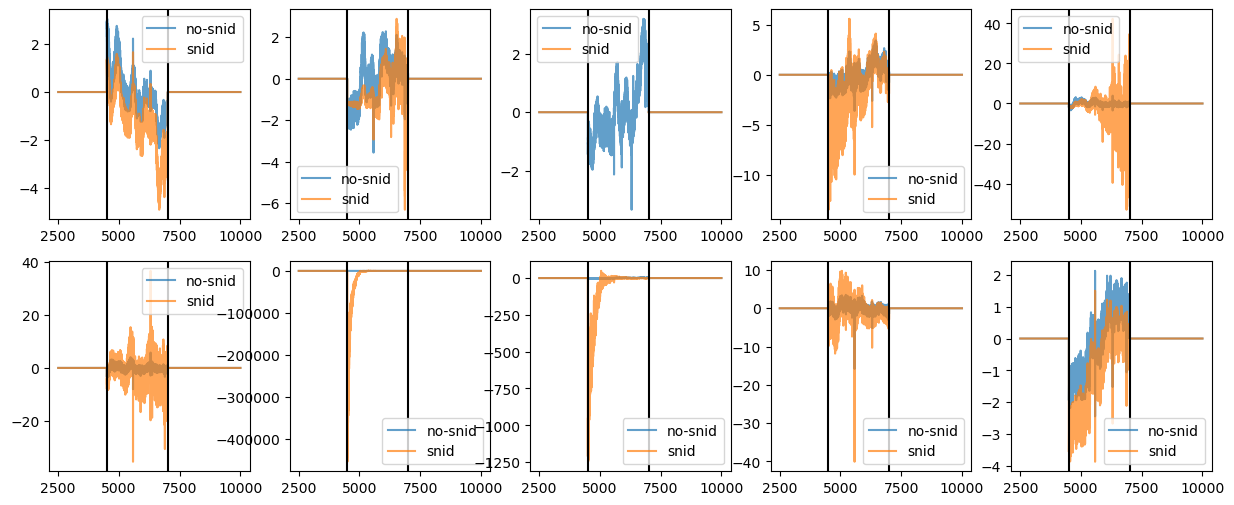

In [39]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
# Flatten the 2D array of axes to easily iterate through all 10 plots sequentially
axes = axes.flatten()
for i in range(10):
    axes[i].plot(log_wave, flux[i], alpha = 0.7, label = "no-snid")
    snid = meanzero(flux[i])
    axes[i].plot(log_wave, snid[0], alpha = 0.7, label = "snid")
    axes[i].axvline(log_wave[snid[1]], color = 'k')
    axes[i].axvline(log_wave[snid[2]], color = 'k')
    axes[i].legend()


In [40]:
snid

(array([0., 0., 0., ..., 0., 0., 0.]),
 15512,
 27172,
 2,
 array([23919. , 26248.5]),
 array([-0.04598726, -0.02540828]))